In [1]:
import numpy as np
import pandas as pd

import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import myutils

import os

sc.settings.verbosity = 3
myutils.set_figure_params()

In [2]:
adata = sc.read_h5ad("1.scRNA_merge_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 195584 × 31129
    obs: 'cell_id', 'sample', 'batch', 'condition', 'condition2', 'description', 'path', 'file_format'

In [3]:
sc.pp.filter_cells(adata, min_genes=300)
sc.pp.filter_genes(adata, min_cells=100)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

filtered out 1239 cells that have less than 300 genes expressed
filtered out 349 genes that are detected in less than 100 cells


/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:315: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(adata.obs[key]):
/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_utils.py:714: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


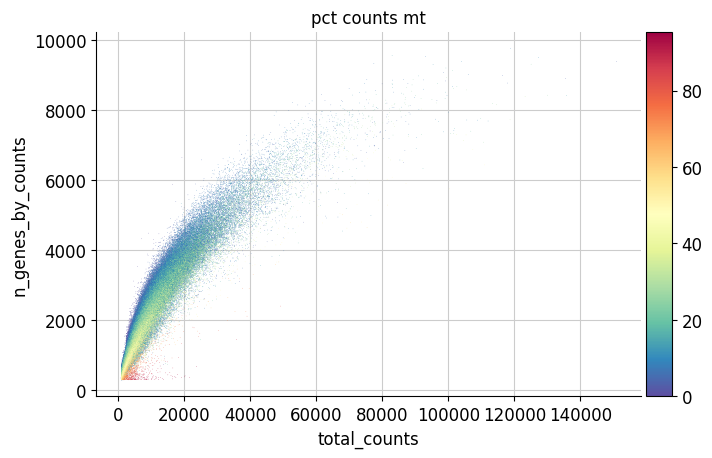

In [4]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',color="pct_counts_mt")

In [5]:
sc.pp.filter_cells(adata, max_counts=80000)
sc.pp.filter_cells(adata, max_genes=8000)
adata = adata[adata.obs.pct_counts_mt < 25, :]
adata

filtered out 131 cells that have more than 80000 counts
filtered out 36 cells that have more than 8000 genes expressed


View of AnnData object with n_obs × n_vars = 178555 × 30780
    obs: 'cell_id', 'sample', 'batch', 'condition', 'condition2', 'description', 'path', 'file_format', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [6]:
myutils.pp.predict_doublets(adata,key_added="doublet", clustering_algorithm="leiden")

/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/site-packages/myutils/_preprocessing/_doubletdetection.py:128: UserWarning: Leiden clustering is experimental and results have not been validated.
  warnings.warn("Leiden clustering is experimental and results have not been validated.")


  0%|          | 0/10 [00:00<?, ?it/s]

computing PCA
Note that scikit-learn's randomized PCA might not be exactly reproducible across different computational platforms. For exact reproducibility, choose `svd_solver='arpack'.`
    with n_comps=30
    finished (0:00:13)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:39)
running Leiden clustering
    finished: found 110 clusters and added
    'clusters', the cluster labels (adata.obs, categorical) (0:04:04)
computing PCA
Note that scikit-learn's randomized PCA might not be exactly reproducible across different computational platforms. For exact reproducibility, choose `svd_solver='arpack'.`
    with n_comps=30
    finished (0:00:14)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['co

/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/site-packages/myutils/_preprocessing/_doubletdetection.py:29: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added+"_label"] = labels


In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125,max_mean=5, min_disp=0.5)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes


/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:215: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


    finished (0:00:05)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [8]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:28)


In [9]:
sc.external.pp.harmony_integrate(adata, 'sample',)

2025-10-18 16:40:25,811 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-18 16:41:02,125 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-18 16:41:02,991 - harmonypy - INFO - Iteration 1 of 10
2025-10-18 16:42:16,623 - harmonypy - INFO - Iteration 2 of 10
2025-10-18 16:43:27,063 - harmonypy - INFO - Iteration 3 of 10
2025-10-18 16:44:36,629 - harmonypy - INFO - Iteration 4 of 10
2025-10-18 16:45:46,754 - harmonypy - INFO - Iteration 5 of 10
2025-10-18 16:46:27,408 - harmonypy - INFO - Converged after 5 iterations


In [10]:
sc.pp.neighbors(adata,use_rep="X_pca_harmony")
sc.tl.umap(adata)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:19)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:03:19)


/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/chenzhizhuo/anaconda3/envs/scanpy/lib/python3.9/sit

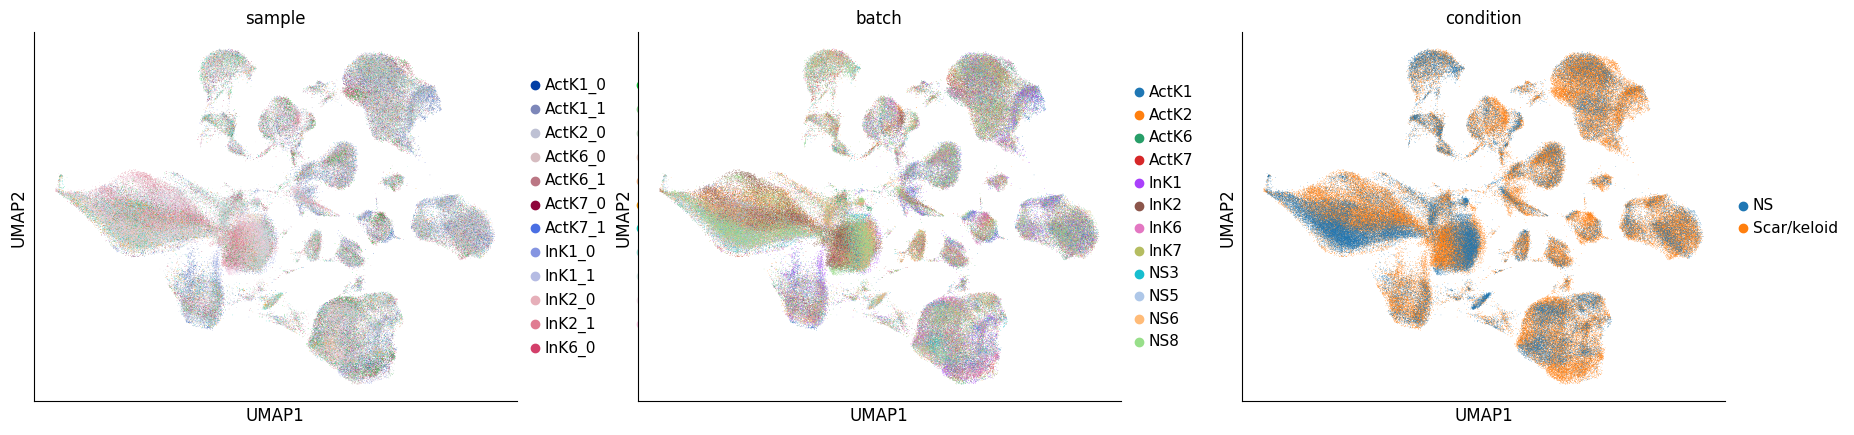

In [11]:
sc.pl.umap(adata,color=["sample","batch","condition"])

In [12]:
adata.write_h5ad("1.2.keloid_merge_preprocessed.h5ad")